<img src="../img/GTK_Logo_Social_Icon.jpg" width=175 align="right" />

# Worksheet 13.1: Agentic Single Email Classifier-Answers
## Building Your First LangGraph Security Agent

**Estimated Time**: 30-40 minutes

### Learning Objectives
- Build a LangGraph `StateGraph` with typed state
- Define nodes and connect them with edges
- Use Pydantic models with `with_structured_output` for reliable classification
- Process emails through a two-node analysis pipeline

### What You'll Build
A two-node graph that takes a raw email and produces a structured phishing verdict:

`START → classify_email → format_verdict → END`

In [ ]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

# Verify API key is set
assert os.getenv("ANTHROPIC_API_KEY"), "Please set ANTHROPIC_API_KEY in your .env file"
print("Environment loaded successfully!")

In [ ]:
import json
from typing import Optional

from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

# Our utilities
import sys
sys.path.insert(0, "..")
from utils.email_loader import load_emails, format_email_for_analysis
from utils.display_helpers import display_verdict, display_batch_results, display_graph_mermaid

In [ ]:
# Load the small 5-email dataset for Lab 1
emails = load_emails(small=True)
print(f"Loaded {len(emails)} emails")

# Preview the first email
print("\n" + format_email_for_analysis(emails[0]))

---
## Step 1: Define the Graph State

In LangGraph, **state** is the data that flows through your graph. Every node receives the current
state, does some work, and returns updates that get merged back into the state.

Think of state as a **shared scratchpad** that every node can read from and write to.

We define state using Python's `TypedDict`, which gives us a dictionary with typed keys. This
tells LangGraph (and our IDE) exactly what data our graph carries:

| Field | Type | Purpose |
|-------|------|---------|
| `email` | `dict` | The raw email data from our dataset |
| `email_text` | `str` | Formatted email string for the LLM to read |
| `classification` | `dict` | Structured classification result from the LLM |
| `verdict_report` | `str` | Final human-readable report |

In [ ]:
class EmailAnalysisState(TypedDict):
    """State that flows through our email analysis graph."""
    email: dict                    # Raw email data
    email_text: str                # Formatted email text for the LLM
    classification: Optional[dict] # Structured classification result
    verdict_report: Optional[str]  # Final formatted report

---
## Step 2: Define Structured Output with Pydantic

When we ask an LLM to classify an email, we don't want freeform text like *"I think this is
probably phishing because..."*. We need **structured, parseable data** that downstream systems
can act on reliably.

**Pydantic models** let us define an exact schema for the LLM's response. When we use
`llm.with_structured_output(EmailClassification)`, LangChain instructs the LLM to return JSON
that matches our schema and automatically validates the result.

This is critical for security automation:
- A SIEM integration needs a machine-readable verdict, not prose
- Confidence scores must be actual numbers, not words like "high" or "medium"
- Downstream rules can trigger on specific field values (e.g., `if verdict == 'phishing'`)

In [ ]:
class EmailClassification(BaseModel):
    """Structured output for email classification."""
    verdict: str = Field(
        description="Classification verdict: 'phishing', 'suspicious', or 'legitimate'"
    )
    confidence: float = Field(
        description="Confidence score between 0.0 and 1.0",
        ge=0.0,
        le=1.0,
    )
    reasoning: str = Field(
        description="Brief explanation of why this classification was chosen"
    )
    indicators: list[str] = Field(
        description="List of specific phishing indicators found (or why it appears legitimate)",
        default_factory=list,
    )

---
## Step 3: Initialize the LLM with Structured Output

We create a `ChatAnthropic` instance and then call `.with_structured_output()` to wrap it with our
Pydantic schema. The resulting `structured_llm` will always return an `EmailClassification`
object instead of a raw string.

Note that `claude-opus-4-8` does not accept a `temperature` parameter, so we simply omit it and
rely on structured output for consistent, parseable security decisions.

In [17]:
llm = ChatAnthropic(model="claude-opus-4-8", max_tokens=4096)
structured_llm = llm.with_structured_output(EmailClassification)

---
## Step 4: Define the Graph Nodes

**Nodes** are the workhorses of a LangGraph graph. Each node is a plain Python function that:
1. Receives the current state as its argument
2. Does some work (call an LLM, transform data, look something up)
3. Returns a dictionary of state updates

LangGraph automatically merges the returned dictionary into the current state.

A good design principle: **each node should do one thing well**.

For our classifier, we need two nodes:
- `classify_email` -- sends the email to the LLM and gets a structured classification
- `format_verdict` -- turns the classification into a human-readable report

In [18]:
def classify_email(state: EmailAnalysisState) -> dict:
    """Node 1: Classify the email using the LLM with structured output."""
    email_text = format_email_for_analysis(state["email"])

    prompt = f"""You are an expert email security analyst. Analyze the following email and classify it.

Consider these phishing indicators:
- Sender address spoofing or lookalike domains (e.g., micros0ft vs microsoft)
- Urgency or pressure tactics ("act now", "immediately", "suspended")
- Suspicious URLs that don't match the claimed sender
- Requests for sensitive information (credentials, financial data, personal info)
- Generic greetings instead of personalized ones
- Grammar and spelling errors
- Mismatched display name and email address
- Suspicious attachments (especially .exe, .zip, .xlsm, .docm)
- Failed email authentication (SPF, DKIM, DMARC)
- Too-good-to-be-true offers or threats

Email to analyze:
{email_text}

Classify this email as 'phishing', 'suspicious', or 'legitimate'."""

    result = structured_llm.invoke(prompt)

    return {
        "email_text": email_text,
        "classification": result.model_dump(),
    }

In [19]:
def format_verdict(state: EmailAnalysisState) -> dict:
    """Node 2: Format the classification into a readable verdict report."""
    c = state["classification"]
    email = state["email"]

    report = f"""
{'='*60}
EMAIL VERDICT REPORT
{'='*60}
Email ID: {email['id']}
Subject: {email['subject']}
From: {email['from_display_name']} <{email['from_address']}>

VERDICT: {c['verdict'].upper()}
CONFIDENCE: {c['confidence']:.0%}

REASONING:
{c['reasoning']}

INDICATORS:
"""
    for indicator in c.get('indicators', []):
        report += f"  \u2022 {indicator}\n"

    report += f"{'='*60}"

    return {"verdict_report": report}

---
## Step 5: Build and Compile the Graph

Now we assemble our nodes into a **StateGraph**. The process is:

1. **Create** a `StateGraph` with our state schema
2. **Add nodes** -- register each function by name
3. **Add edges** -- define the flow between nodes
4. **Compile** -- validate the graph and produce a runnable object

LangGraph provides two special sentinels:
- `START` -- the entry point of the graph
- `END` -- the exit point of the graph

Our graph flow:
```
START --> classify_email --> format_verdict --> END
```

Once compiled, the graph object is callable -- you can `.invoke()` it with an initial state.

In [20]:
# Create the graph
workflow = StateGraph(EmailAnalysisState)

# Add nodes
workflow.add_node("classify_email", classify_email)
workflow.add_node("format_verdict", format_verdict)

# Add edges: START -> classify -> format -> END
workflow.add_edge(START, "classify_email")
workflow.add_edge("classify_email", "format_verdict")
workflow.add_edge("format_verdict", END)

# Compile
graph = workflow.compile()
print("Graph compiled successfully!")

Graph compiled successfully!


### Lab 1: Email Classifier

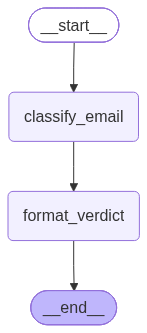

In [21]:
display_graph_mermaid(graph, "Lab 1: Email Classifier")

---
## Step 6: Test with a Single Email

Let's invoke the graph with the first email in our dataset. We pass an initial state dictionary
with the email data and placeholder values for the fields that our nodes will populate.

In [22]:
# Test with the first email
result = graph.invoke({
    "email": emails[0],
    "email_text": "",
    "classification": None,
    "verdict_report": None,
})

print(result["verdict_report"])

# Display color-coded verdict
c = result["classification"]
display_verdict(
    emails[0]["id"],
    c["verdict"],
    c["confidence"],
    c["reasoning"],
)


EMAIL VERDICT REPORT
Email ID: EMAIL-001
Subject: URGENT: Your account has been compromised
From: Microsoft Security Team <security-alert@micros0ft-verify.com>

VERDICT: PHISHING
CONFIDENCE: 99%

REASONING:
This email exhibits numerous classic phishing hallmarks. The sender uses a lookalike domain that substitutes a zero for the letter 'o' (micros0ft-verify.com) to impersonate Microsoft. All three email authentication checks (SPF, DKIM, DMARC) failed, strongly indicating spoofing. The message uses urgency and threat tactics ("URGENT", "compromised", "within 24 hours", "permanently suspended") to pressure the recipient. The embedded URL points to the same fraudulent lookalike domain rather than a legitimate Microsoft domain (e.g., microsoft.com or login.microsoftonline.com), and it directs to a credential-harvesting login page. It also uses a generic greeting ("Dear User") instead of the recipient's name. Collectively these factors make this a clear, high-confidence phishing attempt.



---
## Step 7: Batch Process All Emails

Now let's run all 5 emails through our classifier and compare the results to the ground truth
labels in the dataset. This will tell us how well our simple two-node graph performs.

In [23]:
# Process all 5 emails
results = []
for email in emails:
    result = graph.invoke({
        "email": email,
        "email_text": "",
        "classification": None,
        "verdict_report": None,
    })
    c = result["classification"]
    results.append({
        "email_id": email["id"],
        "verdict": c["verdict"],
        "confidence": c["confidence"],
        "ground_truth": email["ground_truth"],
    })
    display_verdict(email["id"], c["verdict"], c["confidence"], c["reasoning"])

In [24]:
display_batch_results(results)

Email ID,Verdict,Confidence,Ground Truth,Match
EMAIL-001,PHISHING,99%,phishing,✅
EMAIL-026,LEGITIMATE,97%,legitimate,✅
EMAIL-006,PHISHING,98%,phishing,✅
EMAIL-035,LEGITIMATE,88%,legitimate,✅
EMAIL-049,SUSPICIOUS,78%,suspicious,✅


---
## Checkpoint Checklist

Before moving on to Lab 2, verify:

- [ ] Graph compiles without errors
- [ ] Mermaid diagram renders showing: `START` → `classify_email` → `format_verdict` → `END`
- [ ] Each email produces a structured verdict with: verdict, confidence, reasoning, indicators
- [ ] The classifier correctly identifies the 2 phishing emails and 2 legitimate emails
- [ ] The borderline email gets either "suspicious" or "phishing" (both acceptable)

## What's Next?

In **Lab 2**, we'll add security tools that the LLM can call autonomously -- URL reputation
checks, sender verification, and email authentication analysis. Instead of relying purely on
the LLM's judgment, the agent will gather evidence before making a decision.